In [2]:
# Import Basic Packgaes 
import numpy as np
import pandas as pd
from datetime import datetime
import statsmodels as sm
import itertools
import glob
import os
from scipy.signal import argrelextrema
from scipy.signal import find_peaks, peak_widths

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns # advanced vizs
from pandas.plotting import lag_plot

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Set Color Palettes
palette1 = itertools.cycle(sns.color_palette(palette='Set1'))
palette2 = itertools.cycle(sns.color_palette(palette='Set2'))

In [107]:
os.chdir('D:\\TDMS\\Different Test Cases\\New folder')

In [108]:
os.getcwd()

'D:\\TDMS\\Different Test Cases\\New folder'

In [109]:
# current directory csv files
csvs = [x for x in os.listdir('D:\\TDMS\\Different Test Cases\\New folder') if x.endswith('.csv')]
# stats.csv -> stats
fns = [os.path.splitext(os.path.basename(x))[0] for x in csvs]

dic_csv = {}
for i in range(len(fns)):
    dic_csv[fns[i]] = pd.read_csv(csvs[i])

In [113]:
dic_csv.keys()

dict_keys(['3.Right Two Crack at top and Left good', '4.Left Two Crack at top and Right Good', '5.Left Two Crack at top & One crack at bottom & Right good', '6.Right Two Crack at top & One crack at bottom & Left good', '7.Right Two Crack at top & Two crack at bottom & Left good', '8.Left Two Crack at top & Two crack at bottom & Right good'])

In [110]:
for key, df in zip(dic_csv.keys(),dic_csv.values()) :
    df.Time =pd.to_datetime(df.Time)
    df.set_index(['Time'], inplace=True)
    df['Cycle-detect']*=120
    

In [111]:
for i in dic_csv.values():
    # Assuming df is your DataFrame
    pressure_data = i['P1-Water Discharge Pressure']
    # Find peaks in the pressure_data
    peaks, _ = find_peaks(pressure_data)
    #insert the 
    i['Pressure_peaks'] = pressure_data[peaks]


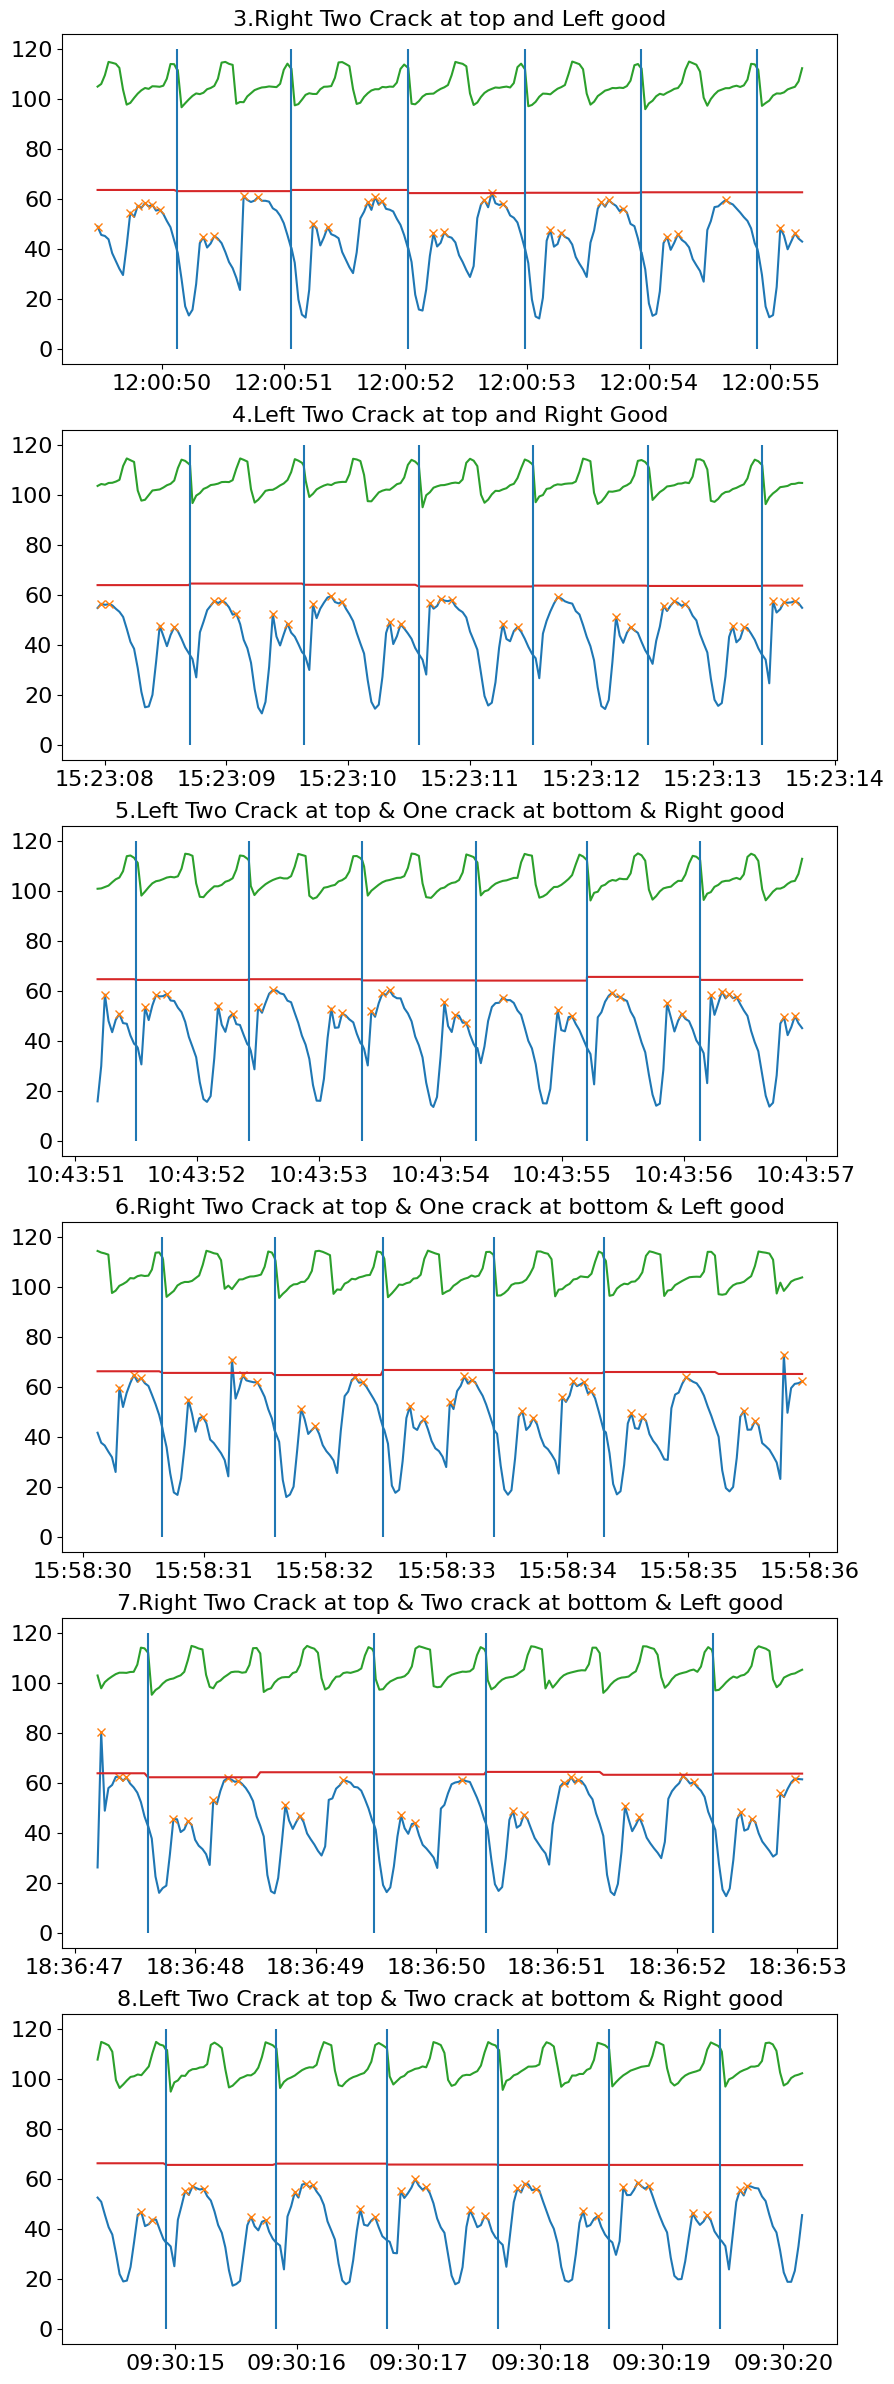

In [129]:
a = len(dic_csv)  # number of rows
b = 1  # number of columns
c = 1  # initialize plot counter

fig1 = plt.figure(figsize=(10,30))

SMALL_SIZE = 16

for j, i in dic_csv.items():
    plt.subplot(a, b, c)
    plt.title(j)
    plt.plot(i.iloc[4900:5100].index, i.iloc[4900:5100]['P1-Water Discharge Pressure'])
    plt.plot(i.iloc[4900:5100].index, i.iloc[4900:5100]['Pressure_peaks'], "x", label="Peaks")
    plt.plot(i.iloc[4900:5100].index, i.iloc[4900:5100]["P1-Air-Supply-pressure"])
    plt.plot(i.iloc[4900:5100].index, i.iloc[4900:5100]["P1-CPM"])
    plt.vlines(x=i.iloc[4900:5100].index, ymin=0, ymax=i.iloc[4900:5100]["Cycle-detect"])
    c = c + 1

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.show()

In [134]:
for i in dic_csv.values():
    i.to_csv(r'D:\\TDMS\\Different Test Cases\\New folder\\3.Right Two Crack at top and Left good_with peaks.csv', index=False)

In [ ]:
dic_csv.keys()

In [ ]:
for i in dic_csv.values():
    i.reset_index(inplace=True)

In [ ]:
i.info()

In [ ]:
df_test_1.set_index('Time', inplace=True)

In [ ]:
df_120ms_res = df_test_1.resample('120ms').mean().asfreq(freq='120ms')

In [ ]:
print(pressure_data[peaks])

In [ ]:
df_pressure_peaks= pd.DataFrame(pressure_data[peaks])

In [ ]:
df_pressure_peaks.head()

In [ ]:
# Find troughs by negating the data and finding peaks in the negated data
    #negated_data = -pressure_data
    #troughs, _ = find_peaks(negated_data)

    # Calculate half-width for the pressure_data peaks
    #results_half_peaks = peak_widths(pressure_data, peaks, rel_height=0.5)

    # Calculate half-width for the pressure_data troughs
    #results_half_troughs = peak_widths(negated_data, troughs, rel_height=0.5)

    # Plot the data
    #plt.plot(i.iloc[10:500].index, i.iloc[10:500]['P1-Water Discharge Pressure'])
    #plt.plot(df_pressure_peaks.iloc[0:90].index[peaks], df_pressure_peaks.iloc[0:90]['0'], "x", label="Peaks")
    #plt.plot(i.iloc[0:50].index[troughs], pressure_data[troughs], "o", label="Troughs")

#plt.hlines(*results_half_peaks[1:], color="C2", label="Half Width Peaks")

#plt.legend()
#plt.show()

In [3]:
df_test_1 = pd.read_csv(r'D:\\TDMS\\Different Test Cases\\New folder\\3.Right Two Crack at top and Left good.csv')

In [4]:
# Assuming df is your DataFrame
pressure_data = df_test_1['P1-Water Discharge Pressure']

# Find peaks in the pressure_data
peaks, _ = find_peaks(pressure_data)

In [5]:
df_test_1['Pressure_peaks'] = pressure_data[peaks]

In [6]:
df_test_1['Time']=pd.to_datetime(df_test_1['Time'])

In [7]:
df_test_1.set_index('Time', inplace=True)

In [8]:
df_test_1.head()

,Cycle-detect,P1-CPM,P1-Water Suction Pressure,P1-Water Discharge Pressure,P1-Channel-3,P1-Air-Supply-pressure,P1-Water Suction Flowrate,P1-Water Discharge Flowrate,P1-Air Supply Flowrate,Pressure_peaks
Time,,,,,,,,,,
2023-08-23 11:57:14.072,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
2023-08-23 11:57:14.102,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
2023-08-23 11:57:14.132,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
2023-08-23 11:57:14.163,0.0,0.0,14.129876,14.150580,14.010488,14.080534,-1.041293,-0.085823,6.091703,14.15058
2023-08-23 11:57:14.192,0.0,0.0,14.129876,14.080534,13.940442,14.080534,-0.954432,-0.085823,6.026538,NaN


In [26]:
start_date = '2023-08-23 12:57:14.163'
end_date = '2023-08-23 12:57:40.192	'
sliced_df = df_test_1[start_date:end_date]

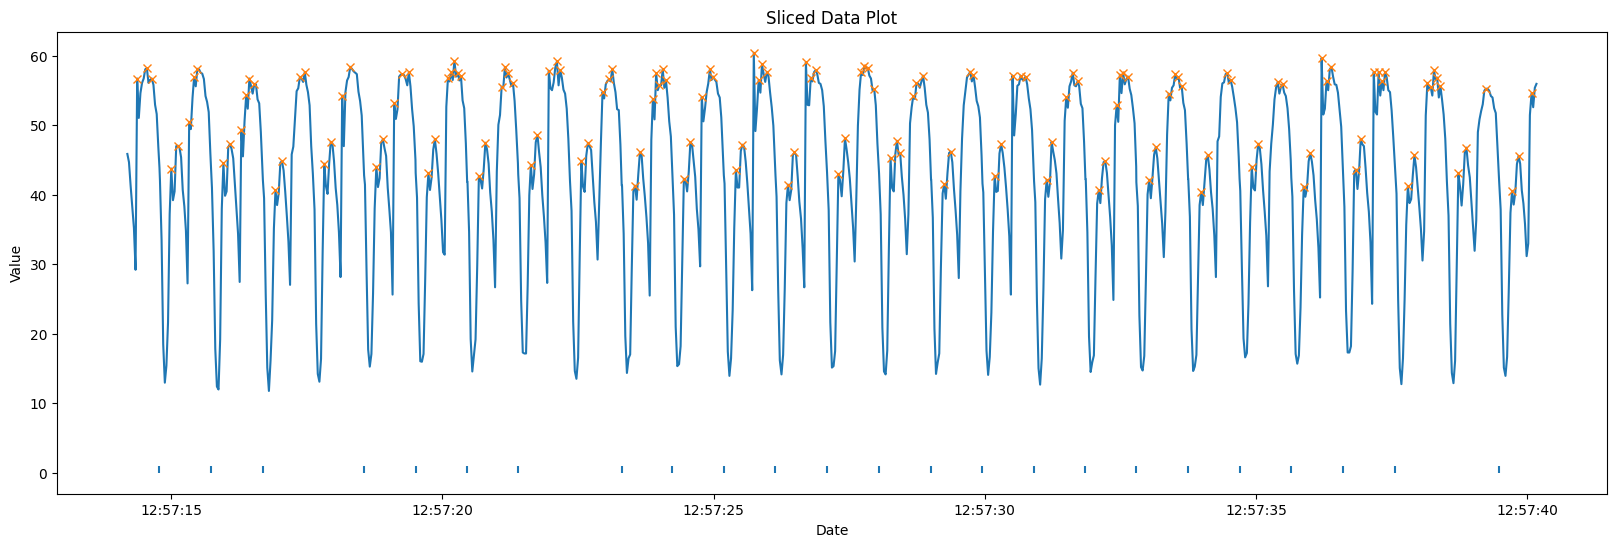

In [27]:
plt.figure(figsize=(20, 6))
plt.plot(sliced_df.index, sliced_df['P1-Water Discharge Pressure'])
plt.plot(sliced_df.index, sliced_df['Pressure_peaks'], "x", label="Peaks")
plt.vlines(x=sliced_df.index, ymin=0, ymax=sliced_df["Cycle-detect"])
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Sliced Data Plot')
plt.show()

In [ ]:
plt.plot(df_120ms_res.iloc[4900:4925].index, df_120ms_res.iloc[4900:4925]['P1-Water Discharge Pressure'])
plt.plot(df_120ms_res.iloc[4900:4925].index, df_120ms_res.iloc[4900:4925]['Pressure_peaks_120'], "x", label="Peaks")

In [ ]:
df_90ms_res = df_test_1.resample('70ms').mean().asfreq(freq='70ms')

In [ ]:
# Assuming df is your DataFrame
pressure_data_90 = df_90ms_res['P1-Water Discharge Pressure']

# Find peaks in the pressure_data
peaks_90, _ = find_peaks(pressure_data_90)

In [ ]:
df_90ms_res['Pressure_peaks_90'] = pressure_data_90[peaks_90]

In [ ]:
df_90ms_res.reset_index(inplace=True)

In [ ]:
df_90ms_res['Cycle-detect']*=5

In [ ]:
plt.figure(figsize=(30,10))
plt.xrange

plt.plot(df_90ms_res.iloc[4900:5450].index, df_90ms_res.iloc[4900:5450]['P1-Water Discharge Pressure'])
plt.plot(df_90ms_res.iloc[4900:5450].index, df_90ms_res.iloc[4900:5450]['Pressure_peaks_90'], "x", label="Peaks")
plt.plot(df_90ms_res.iloc[4900:5450].index, df_90ms_res.iloc[4900:5450]["P1-Air-Supply-pressure"])
plt.plot(df_90ms_res.iloc[4900:5450].index, df_90ms_res.iloc[4900:5450]["P1-CPM"])
plt.vlines(x=df_90ms_res.iloc[4900:5450].index, ymin=0, ymax=df_90ms_res.iloc[4900:5450]["Cycle-detect"])
